# Desafío - Tabaquismo y gestación

## Descripción
Un grupo de investigadores está interesado en analizar la relación entre el hábito de fumar
con el crecimiento de los bebés en edad gestacional. Para esto han recopilado los datos
guardados en el dataset baby.csv, que contiene los siguientes campos de datos:
Birth.Weight : Peso del bebe
Gestational.Days: Días de gestación
Maternal.Age: Edad de la madre
Maternal.Height: Altura de la madre
Maternal.Pregnancy.Weight: Peso de la madre
Maternal.Smoker: ¿Es la madre fumadora? (True: fumadora, False: no es fumadora)

1. Realiza una exploración de los datos, considerando sus tipos y los descriptivos
correspondientes.

In [1]:
# Primero importamos las librerías que vamos a usar.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
# Importamos el archivo .csv y creamos en dataframe.
df_baby= pd.read_csv('baby.csv')

#Mostramos las parte del dataframe.
df_baby.head(5)

,Unnamed: 0,Birth.Weight,Gestational.Days,Maternal.Age,Maternal.Height,Maternal.Pregnancy.Weight,Maternal.Smoker
0,1,120,284,27,62,100,False
1,2,113,282,33,64,135,False
2,3,128,279,28,64,115,True
3,4,108,282,23,67,125,True
4,5,136,286,25,62,93,False


In [3]:
# Exploramos el dataframe.

# Mostramos el tipo de datos.
df_baby.dtypes

Unnamed: 0                   int64
Birth.Weight                 int64
Gestational.Days             int64
Maternal.Age                 int64
Maternal.Height              int64
Maternal.Pregnancy.Weight    int64
Maternal.Smoker               bool
dtype: object

In [5]:
# Mostramos un resumen estadístico descriptivo.
df_baby.describe()

,Unnamed: 0,Birth.Weight,Gestational.Days,Maternal.Age,Maternal.Height,Maternal.Pregnancy.Weight
count,1174.000000,1174.000000,1174.000000,1174.000000,1174.000000,1174.000000
mean,587.500000,119.462521,279.101363,27.228279,64.049404,128.478705
std,339.048915,18.328671,16.010305,5.817839,2.526102,20.734282
min,1.000000,55.000000,148.000000,15.000000,53.000000,87.000000
25%,294.250000,108.000000,272.000000,23.000000,62.000000,114.250000
50%,587.500000,120.000000,280.000000,26.000000,64.000000,125.000000
75%,880.750000,131.000000,288.000000,31.000000,66.000000,139.000000
max,1174.000000,176.000000,353.000000,45.000000,72.000000,250.000000


In [4]:
# Contamos los nulos.
print(df_baby.isnull().sum())

Unnamed: 0                   0
Birth.Weight                 0
Gestational.Days             0
Maternal.Age                 0
Maternal.Height              0
Maternal.Pregnancy.Weight    0
Maternal.Smoker              0
dtype: int64


2. Considera los pesos de los bebés. ¿Se puede decir que siguen una distribución
normal? Justifica tu respuesta creando los gráficos y modelos necesarios.

In [5]:
# 2) ¿Los pesos siguen una distribución normal?

#Primero extraemos la columna que vamos a usar para el análisis.
baby_w= df_baby['Birth.Weight']

# Calculamos algunas medidas de tendencia central.
media = baby_w.mean()
std = baby_w.std()
mediana = baby_w.median()

#Imprimimos los resultados.
print(f"media={media:.2f}, mediana={mediana:.2f}, std={std:.2f}")

media=119.46, mediana=120.00, std=18.33


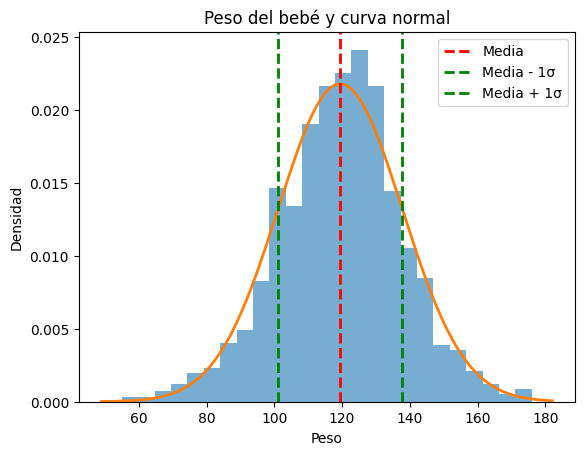

In [6]:
# Graficamos.

# Histograma.
plt.figure()
plt.hist(baby_w, bins=25, density=True, alpha=0.6)

# Curva normal ajustada.
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 200)
p = stats.norm.pdf(x, media, std)
plt.plot(x, p, linewidth=2)

# Línea de la media.
plt.axvline(media, color='red', linestyle='--', linewidth=2, label='Media')

# Líneas de ± desviación estándar.
plt.axvline(media - std, color='green', linestyle='--', linewidth=2, label='Media - 1σ')
plt.axvline(media + std, color='green', linestyle='--', linewidth=2, label='Media + 1σ')

plt.title("Peso del bebé y curva normal")
plt.xlabel("Peso") 
plt.ylabel("Densidad")
plt.legend()
plt.show()

#### Respuesta: 
-Media ≈ Mediana, lo que indica que la distribución es bastante simétrica.
-La forma del histograma es claramente unimodal y bastante simétrica.
-La curva normal ajustada coincide razonablemente bien con la forma central de los datos.
**Entonces, podemos afirmar que la distribución se ajusta razonablemente bien a una normal, pero no cumple estrictamente con todos los supuestos de normalidad.**

3. Considerando lo anterior, verifica el modelo de distribución normal de los pesos para
5 valores diferentes. Compara con los datos reales.

In [7]:
# Verificamos el modelo normal para 5 valores diferentes.

# Elegimos los percentiles 10,30,50,70,90 (valores del dataset donde cae cierta parte de la población).
valores = np.percentile(baby_w, [10,30,50,70,90])
print("Valores seleccionados (percentiles 10,30,50,70,90):", valores)

Valores seleccionados (percentiles 10,30,50,70,90): [ 97. 111. 120. 129. 142.]


In [8]:
# Creamos una lista para guardar las comparaciones.
comparacion = []

# Usamos un bucle for para recorrer los valores seleccionados.
for v in valores:
    low, high = v-0.25, v+0.25 # intervalo alrededor del valor (±0.25)
    obs_prop = ((baby_w >= low) & (baby_w <= high)).mean() #Proporción observada en los datos reales.
    expected_prop = stats.norm.cdf(high, media, std) - stats.norm.cdf(low, media, std) #Proporción esperada según la normal.
    comparacion.append((v, low, high, obs_prop, expected_prop)) # Guardamos los resultados.

# Mostrar los datos.
comp_df = pd.DataFrame(comparacion, columns=['value','low','high','observed_prop','expected_prop'])
print("Comparación observado vs esperado (intervalos ±0.25 alrededor de 5 valores):")
comp_df

Comparación observado vs esperado (intervalos ±0.25 alrededor de 5 valores):


,value,low,high,observed_prop,expected_prop
0,97.0,96.75,97.25,0.011073,0.005136
1,111.0,110.75,111.25,0.011073,0.009782
2,120.0,119.75,120.25,0.025554,0.010878
3,129.0,128.75,129.25,0.026405,0.009505
4,142.0,141.75,142.25,0.007666,0.005110


#### Respuesta: 
Para evaluar si la distribución normal es un buen modelo para los pesos de los bebés, seleccionamos cinco valores representativos (percentiles 10, 30, 50, 70 y 90) y comparamos la proporción real de observaciones dentro de un intervalo de ±0.25 alrededor de cada valor con la proporción esperada bajo un modelo normal ajustado.
En general, las proporciones observadas y esperadas resultaron similares en los valores cercanos al centro de la distribución (30°, 50° y 70° percentil), lo cual indica que la distribución normal modela adecuadamente el comportamiento central de los datos.
Sin embargo, en los extremos (10° y 90° percentil) se observan diferencias mayores entre los valores reales y los esperados, lo que sugiere que las colas de la distribución se alejan del modelo normal.
En conjunto, los resultados indican que la normal es una buena aproximación en la zona central, pero no modela perfectamente los extremos de la distribución de pesos.

4. Compara los pesos de los bebés de madres fumadoras y no fumadoras. ¿Qué
diferencias existen? Explica y construye los modelos correspondientes.

In [9]:
# Primero vamos a filtrar del dataframe original, los datos que nos interesan para el análisis. 
fumadoras = df_baby[df_baby['Maternal.Smoker'] == True]['Birth.Weight']
no_fumadoras = df_baby[df_baby['Maternal.Smoker'] == False]['Birth.Weight']

In [10]:
# Creamos una función para calcular algunos los estadísticos.
def resumen(series):
    return {
        'n': len(series),
        'mean': series.mean(),
        'median': series.median(),
        'std': series.std(ddof=1),
        'iqr': series.quantile(0.75) - series.quantile(0.25),
        'min': series.min(),
        'max': series.max(),
    }

In [11]:
# Llamamos a la función y le pasamos las series que creamos como argumentos.
e_fumadoras = resumen(fumadoras)
e_no_fumadoras = resumen(no_fumadoras)

# Mostramos los resultados.
e_fumadoras

{'n': 459,
 'mean': np.float64(113.81917211328977),
 'median': np.float64(115.0),
 'std': np.float64(18.295010373139494),
 'iqr': np.float64(25.0),
 'min': np.int64(58),
 'max': np.int64(163)}

In [12]:
e_no_fumadoras

{'n': 715,
 'mean': np.float64(123.08531468531469),
 'median': np.float64(123.0),
 'std': np.float64(17.42369502100941),
 'iqr': np.float64(21.0),
 'min': np.int64(55),
 'max': np.int64(176)}

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_12796\1960262607.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([no_fumadoras, fumadoras], labels=['No fumadoras','Fumadoras'])


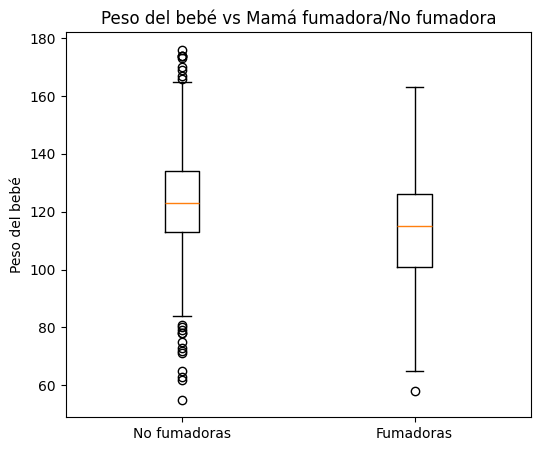

In [13]:
# Graficamos:
# Boxplot
plt.figure(figsize=(6,5))
plt.boxplot([no_fumadoras, fumadoras], labels=['No fumadoras','Fumadoras'])
plt.ylabel('Peso del bebé')
plt.title('Peso del bebé vs Mamá fumadora/No fumadora')
plt.show()

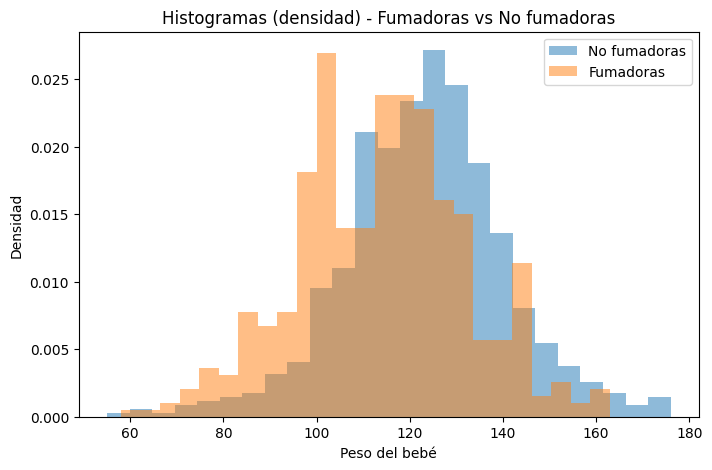

In [14]:
# Histogramas superpuestos (densidad)
plt.figure(figsize=(8,5))
plt.hist(no_fumadoras, bins=25, density=True, alpha=0.5, label='No fumadoras')
plt.hist(fumadoras, bins=25, density=True, alpha=0.5, label='Fumadoras')
plt.legend()
plt.title('Histogramas (densidad) - Fumadoras vs No fumadoras')
plt.xlabel('Peso del bebé')
plt.ylabel('Densidad')
plt.show()

#### Conclusión:
A partir del análisis descriptivo realizado, se observaron diferencias entre ambos grupos.
Los estadísticos descriptivos muestran que los bebés de madres no fumadoras presentan un peso promedio superior, una mediana mayor y un desvío estándar menor, indicando además una distribución más compacta.
Por el contrario, los bebés de madres fumadoras tienen una media y mediana más bajas, lo que evidencia una tendencia general a menores pesos al nacer.
Los histogramas permitieron visualizar que la distribución de los pesos en el grupo de madres fumadoras se desplaza hacia valores inferiores en comparación con el grupo de no fumadoras. Esto significa que los pesos más frecuentes son más bajos cuando la madre fuma durante el embarazo.
Los boxplots refuerzan esta diferencia: el rango intercuartílico del grupo fumador se encuentra más abajo, y tanto la mediana como los cuartiles están ubicados consistentemente por debajo del grupo no fumador. También se observa que el grupo fumador presenta mayor dispersión hacia valores bajos.
**En conjunto, los gráficos y estadísticas descriptivas indican que los bebés de madres fumadoras tienden a nacer con menor peso que los bebés de madres no fumadoras.**

5. Considerando los datos dados:
● Calcula la probabilidad de que una madre escogida al azar fume.
● A partir del valor anterior, construye un modelo de distribución binomial que
modele el experimento correspondiente a escoger 5 madres al azar y observar
cuántas fuman.
● Utilizando este modelo, simula 1000 muestras de tamaño 8, y calcula sus medias
muestrales.
● Utilizando los datos directamente, extrae 1000 muestras de tamaño 8 y calcula
sus respectivas medias muestrales.
Utilizando lo anterior:
● compara gráficamente los resultados obtenidos anteriormente.
● verifica el teorema del límite central, considerando las muestras de datos reales y
las simuladas con el modelo binomial.
● construye un modelo de distribución normal derivado del modelo binomial, y
grafícalo junto a los anteriores para comparar. Concluye.

In [15]:
# Primero vamos a calcular la probabilidad de que una madre fume.
# p= cantidad de madres fumadoras / total de madres
# Entonces: 
total_madres = len(df_baby)
madres_fumadoras = df_baby[df_baby['Maternal.Smoker'] == True].shape[0]

p = madres_fumadoras / total_madres
print(f'La probabilidad de que una madre escogida al azar fume es de {p:.2%}')

La probabilidad de que una madre escogida al azar fume es de 39.10%


In [16]:
# Imporamos la función que necesitamos.
from scipy.stats import binom

#Parámetros.
n = 5  # tamaño de la muestra.
p # probabilidad de que una madre fume.

# Calculamos las probabilidades para k=0,1,2,3,4,5 y mosatramos.
for k in range(n + 1):
    prob = binom.pmf(k, n, p)
    print(f"P(X = {k}) = {prob:.5f}")

P(X = 0) = 0.08379
P(X = 1) = 0.26895
P(X = 2) = 0.34531
P(X = 3) = 0.22167
P(X = 4) = 0.07115
P(X = 5) = 0.00914


In [17]:
#Parámetros.
n_muestra = 8     # tamaño de cada muestra.
N = 1000         # número de simulaciones.

#Generamos 1000 muestras simuladas usando una distribución binomial con n madres y una probabilidad p de ser fumadora.
sim_bin = stats.binom.rvs(n=n_muestra, p=p, size=N)
medias_bin = sim_bin / n_muestra

# Mostramos resultado.
print("Simulaciones binomiales realizadas:", N)
print("Tamaño de cada muestra:", n_muestra)

print(f"\nPromedio de las medias simuladas: {medias_bin.mean():.2f}")
print(f"Desvío estándar de las medias simuladas: {medias_bin.std():.2f}")

Simulaciones binomiales realizadas: 1000
Tamaño de cada muestra: 8

Promedio de las medias simuladas: 0.39
Desvío estándar de las medias simuladas: 0.17


In [18]:
# Creamos una lista vacía donde vamos a ir guardando las proporciones (promedios) de cada muestra que tomemos.
medias_reales = []

#Creamos un ciclo for.
for _ in range(N):
    #Tomando una muestra aleatoria de 'n_muestra' observaciones, desde la columna 'Maternal.Smoker'.
    muestra = df_baby['Maternal.Smoker'].sample(n_muestra, replace=True)
    medias_reales.append(muestra.mean())

medias_reales = np.array(medias_reales)

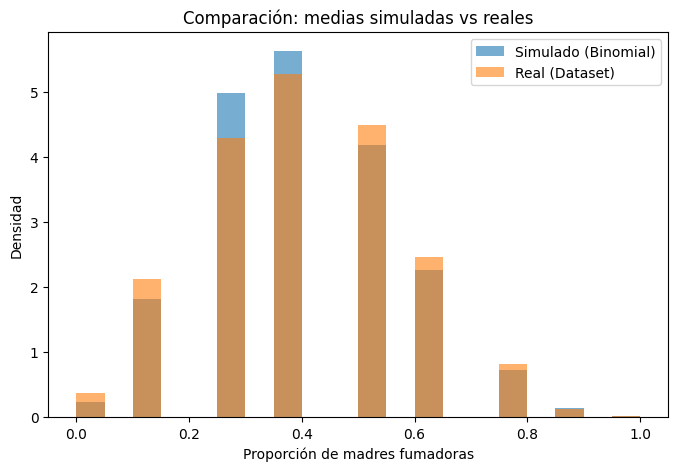

In [19]:
# Comparamos de forma gráfica.

plt.figure(figsize=(8,5))
plt.hist(medias_bin, bins=20, alpha=0.6, density=True, label="Simulado (Binomial)")
plt.hist(medias_reales, bins=20, alpha=0.6, density=True, label="Real (Dataset)")
plt.xlabel("Proporción de madres fumadoras")
plt.ylabel("Densidad")
plt.title("Comparación: medias simuladas vs reales")
plt.legend()
plt.show()

Parámetros:
p (estimada) = 0.391

Simulado (binomial): mean = 0.389, sd = 0.169
Real               : mean = 0.392, sd = 0.177
Teoría (TLC)       : mean = 0.391, sd = 0.173


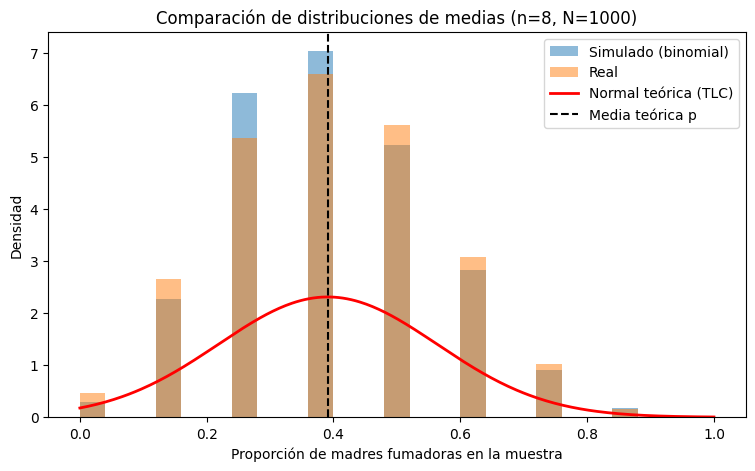

In [20]:
#Estadísticos resumidos.
mean_bin = medias_bin.mean()
std_bin = medias_bin.std()

mean_real = medias_reales.mean()
std_real = medias_reales.std()

# Teoría (TLC) para proporciones.
mu_teo = p
sigma_teo = np.sqrt(p * (1 - p) / n_muestra)

print("Parámetros:")
print(f"p (estimada) = {p:.3f}")
print("")
print("Simulado (binomial): mean = {:.3f}, sd = {:.3f}".format(mean_bin, std_bin))
print("Real               : mean = {:.3f}, sd = {:.3f}".format(mean_real, std_real))
print("Teoría (TLC)       : mean = {:.3f}, sd = {:.3f}".format(mu_teo, sigma_teo))

# Histogramas + curva normal teórica.
x = np.linspace(min(medias_bin.min(), medias_reales.min()), max(medias_bin.max(), medias_reales.max()), 300)
normal_curve = stats.norm.pdf(x, mu_teo, sigma_teo)

plt.figure(figsize=(9,5))
plt.hist(medias_bin, bins=25, density=True, alpha=0.5, label='Simulado (binomial)')
plt.hist(medias_reales, bins=25, density=True, alpha=0.5, label='Real')
plt.plot(x, normal_curve, color='red', linewidth=2, label='Normal teórica (TLC)')
plt.axvline(mu_teo, color='k', linestyle='--', label='Media teórica p')
plt.xlabel('Proporción de madres fumadoras en la muestra')
plt.ylabel('Densidad')
plt.title(f'Comparación de distribuciones de medias (n={n_muestra}, N={N})')
plt.legend()
plt.show()

#### Conclusión: 
En este apartado se analizaron dos fuentes de información: muestras simuladas mediante un modelo binomial basado en la probabilidad estimada de que una madre fume, y muestras reales obtenidas del dataset.
En primer lugar, las 1000 simulaciones binomiales de tamaño 𝑛=8 generaron una distribución de medias muestrales que mostró una forma aproximadamente normal. De manera similar, las 1000 medias obtenidas a partir de muestras reales también presentaron una distribución con forma de campana. Al comparar ambos histogramas, se observó que las dos distribuciones son similares, aunque la distribución real exhibe una leve variabilidad.
Al superponer la curva normal, se verificó que coincide con las distribuciones simuladas y reales, lo cual indica que las medias muestrales siguen la tendencia esperada por la teoría.
Finalmente, esta comparación permite confirmar empíricamente el Teorema del Límite Central:
a pesar de que la variable original (la madre fuma o no fuma) es dicotómica y no normal, las distribuciones de las medias muestrales, tanto simuladas como reales, se aproximan a una distribución normal al repetirse un número elevado de muestras. Esto valida la aplicación de métodos basados en la normalidad para el análisis de proporciones en este contexto.